In [1]:
import pandas as pd
import plotly.express as px # add this
import plotly.io as pio
# from sklearn.manifold import TSNE
import glasbey # add this
import os
import h5py # add this
import numpy as np
from sklearn.decomposition import PCA
import openTSNE # add this

pio.renderers.default = 'browser'

In [2]:
# read in matlab output
mat_filename = r"X:\3darena_behavior\wildtype_062425\011725_9\011725_9_3d_arenah_070225\cluster_output\Combined_Results\Results\test1\session_1_out.mat"

# "C:\Users\gangliagurdian\Desktop\Mias Folder\data testing\10min testing\Combined_Results\Results\test1\session_1_out.mat"
# "Z:\socialbox_fp\C2_042125_C3_042125_gpe\C2_042125\042125_1\open_field_061625\day_1\042125_1_tdt_rt_061625of\Bonsai - Copy\AccelCluster_Output - Copy\Combined_Results\Results\test1\session_1_out.mat"

In [3]:
# extract similarity matrix & cluster labels
if os.path.exists(mat_filename):
    with h5py.File(mat_filename, 'r') as file:
        clusters = file['Clusters']
        similarity_matrix = clusters['sim'][()]

        cluster_labels = clusters["idx"][()]
else:
    raise FileNotFoundError('Could not find session_1_out.mat in dedicated subdirectory')

print(similarity_matrix.shape)
print(cluster_labels.shape)

# transpose cluster_labels
cluster_labels = cluster_labels.T

# turn clusters_labels into 1D array
cluster_labels = cluster_labels.flatten()
print(cluster_labels.shape)

(47715, 47715)
(1, 47715)
(47715,)


In [4]:
# apply PCA to reduce dimensions to 50
pca = PCA(n_components=50)
similarity_matrix_reduced = pca.fit_transform(similarity_matrix)
print(similarity_matrix_reduced.shape)

(47715, 50)


Testing Metric parameter

In [13]:
print("Data set contains %d samples with %d features" % similarity_matrix_reduced.shape)

Data set contains 47715 samples with 50 features


In [15]:
# Standard t-SNE with openTSNE
%%time
embedding_standard = openTSNE.TSNE(
    perplexity=30,
    initialization="random",
    metric="euclidean",
    n_jobs=8,
    random_state=3,
).fit(similarity_matrix_reduced)


CPU times: total: 8min 46s
Wall time: 2min 1s


In [42]:
cluster_labels_str = [str(c) for c in cluster_labels]
cluster_names = sorted(set(cluster_labels_str))

import glasbey
glasbey_palette = glasbey.create_palette(palette_size=len(cluster_names))
cluster_to_color = {
    name: glasbey_palette[i]
    for i, name in enumerate(cluster_names)
}


def plot_single(data, **kwargs):
    fig = px.scatter(
        x=data[:, 0],
        y=data[:, 1],
        color=cluster_labels_str,
        title='openTSNE Multiscale Visualization of Similarity Matrix',
        color_discrete_map=cluster_to_color,
        labels={'x': 't-SNE 1', 'y': 't-SNE 2'}
    )

    print(f"Embedding shape: {data.shape}")

    fig.update_traces(marker=dict(size=5))
    fig.show()

In [17]:
plot(embedding_standard)

Embedding shape: (47715, 2)


In [19]:
# PCA initialization t-SNE with openTSNE
%%time
embedding_pca = openTSNE.TSNE(
    perplexity=30,
    initialization="pca",
    metric="euclidean",
    n_jobs=8,
    random_state=3,
).fit(similarity_matrix_reduced)

CPU times: total: 8min 29s
Wall time: 1min 51s


In [20]:
plot(embedding_pca)

Embedding shape: (47715, 2)


In [ ]:
# Cosine distance t-SNE with openTSNE
%%time
embedding_cosine = openTSNE.TSNE(
    perplexity=30,
    initialization="random",
    metric="cosine",
    n_jobs=8,
    random_state=3,
).fit(similarity_matrix_reduced)

In [24]:
plot(embedding_cosine)

Embedding shape: (47715, 2)


In [26]:
%%time
embedding_pca_cosine = openTSNE.TSNE(
    perplexity=30,
    initialization="pca",
    metric="cosine",
    n_jobs=8,
    random_state=3,
).fit(similarity_matrix_reduced)
# PCA initialization + cosine distance t-SNE with openTSNE

CPU times: total: 8min 45s
Wall time: 1min 55s


In [27]:
plot(embedding_pca_cosine)

Embedding shape: (47715, 2)


In [32]:
# Summary
import matplotlib.pyplot as plt
from plotly.subplots import make_subplots
import plotly.graph_objects as go
pio.renderers.default = 'notebook'

fig, ax = make_subplots(rows=2, cols=2)
plot(embedding_standard, title="Standard t-SNE", ax=ax[0, 0], draw_legend=False)
plot(embedding_pca, title="PCA initialization", ax=ax[0, 1], draw_legend=False)
plot(embedding_cosine, title="Cosine distance", ax=ax[1, 0], draw_legend=False)
plot(embedding_pca_cosine, title="PCA initialization + Cosine distance", ax=ax[1, 1], draw_legend=False)
plt.tight_layout()

ValueError: too many values to unpack (expected 2)

In [35]:
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import plotly.io as pio

pio.renderers.default = "browser"

fig = make_subplots(
    rows=2,
    cols=2,
    subplot_titles=[
        "Standard t-SNE",
        "PCA initialization",
        "Cosine distance",
        "PCA initialization + Cosine distance"
    ]
)

def plot(fig, data, row, col):
    print(f"Embedding shape: {data.shape}")

    fig.add_trace(
        go.Scatter(
            x=data[:, 0],
            y=data[:, 1],
            mode="markers",
            marker=dict(
                size=5,
                color=[cluster_to_color[c] for c in cluster_labels_str]
            ),
            text=cluster_labels_str,
            showlegend=False
        ),
        row=row,
        col=col
    )


plot(fig, embedding_standard, 1, 1)
plot(fig, embedding_pca, 1, 2)
plot(fig, embedding_cosine, 2, 1)
plot(fig, embedding_pca_cosine, 2, 2)

fig.update_layout(
    height=800,
    width=800,
    title="openTSNE Multiscale Visualization of Similarity Matrix"
)

fig.show()

Embedding shape: (47715, 2)
Embedding shape: (47715, 2)
Embedding shape: (47715, 2)
Embedding shape: (47715, 2)


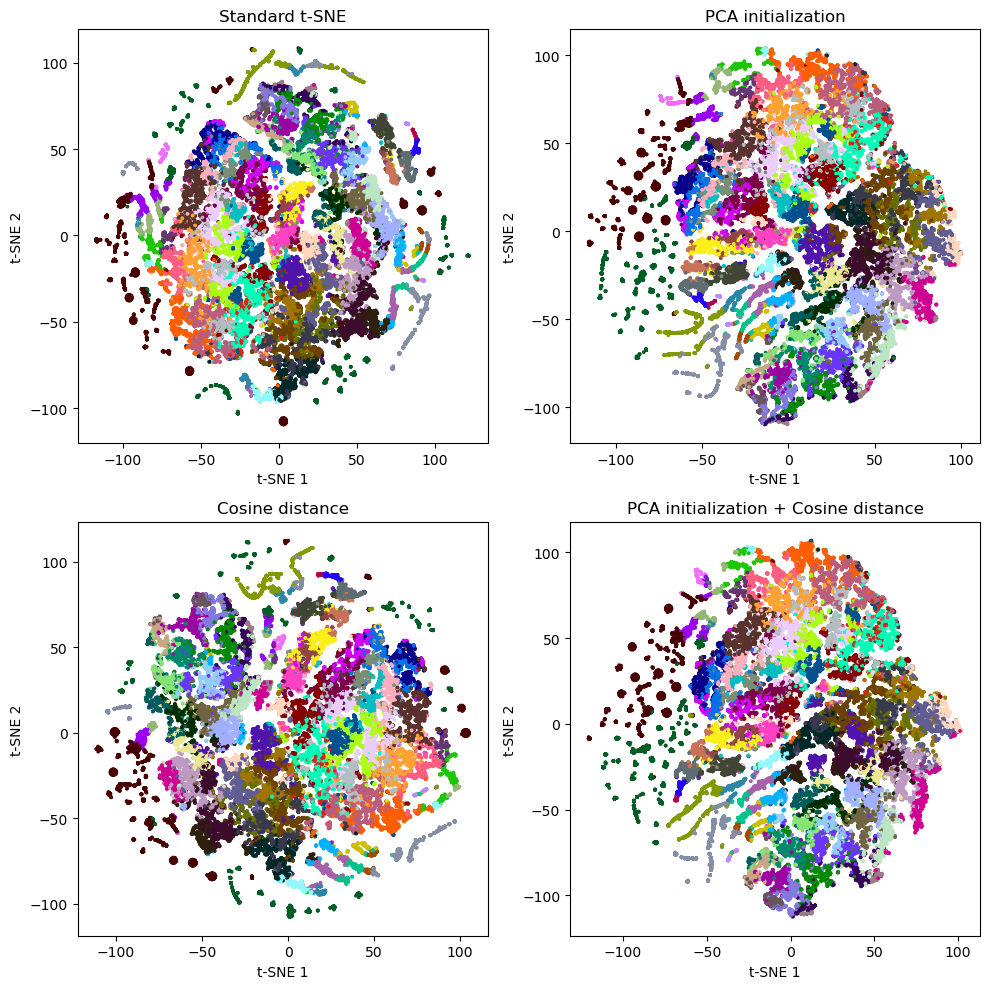

In [38]:
import matplotlib.pyplot as plt

def plot(data, ax, title):
    colors = [cluster_to_color[c] for c in cluster_labels_str]

    ax.scatter(
        data[:, 0],
        data[:, 1],
        c=colors,
        s=3
    )

    ax.set_title(title)
    ax.set_xlabel("t-SNE 1")
    ax.set_ylabel("t-SNE 2")


fig, ax = plt.subplots(2, 2, figsize=(10, 10))

plot(embedding_standard, ax[0, 0], "Standard t-SNE")
plot(embedding_pca, ax[0, 1], "PCA initialization")
plot(embedding_cosine, ax[1, 0], "Cosine distance")
plot(embedding_pca_cosine, ax[1, 1], "PCA initialization + Cosine distance")

plt.tight_layout()
plt.show()

perplexity 500

In [40]:
%%time
embedding_pca_cosine_500 = openTSNE.TSNE(
    perplexity=500,
    initialization="pca",
    metric="cosine",
    n_jobs=8,
    random_state=3,
).fit(similarity_matrix_reduced)

CPU times: total: 18min 41s
Wall time: 2min 33s


In [43]:
plot_single(embedding_pca_cosine_500)

Embedding shape: (47715, 2)


In [ ]:
%%time
embedding_annealing = openTSNE.TSNE(
    perplexity=500, 
    metric="cosine", 
    initialization="pca", 
    n_jobs=8, 
    random_state=3
).fit(similarity_matrix_reduced)

# perplexity 500 annealing

CPU times: total: 18min 44s
Wall time: 2min 31s


In [45]:
%time embedding_annealing.affinities.set_perplexities([50])

CPU times: total: 11 s
Wall time: 1.79 s


In [46]:
%time embedding_annealing = embedding_annealing.optimize(250)

CPU times: total: 3min 58s
Wall time: 51.9 s


In [47]:
plot_single(embedding_annealing)

Embedding shape: (47715, 2)


In [48]:
%%time
affinities_multiscale_mixture = openTSNE.affinity.Multiscale(
    similarity_matrix_reduced,
    perplexities=[50, 500],
    metric="cosine",
    n_jobs=8,
    random_state=3,
)
# multiscale 

CPU times: total: 5min 57s
Wall time: 58.9 s


In [49]:
%time init = openTSNE.initialization.pca(similarity_matrix_reduced, random_state=42)

CPU times: total: 250 ms
Wall time: 16.6 ms


In [50]:
embedding_multiscale = openTSNE.TSNE(n_jobs=8).fit(
    affinities=affinities_multiscale_mixture,
    initialization=init,
)

In [51]:
plot_single(embedding_multiscale)

Embedding shape: (47715, 2)


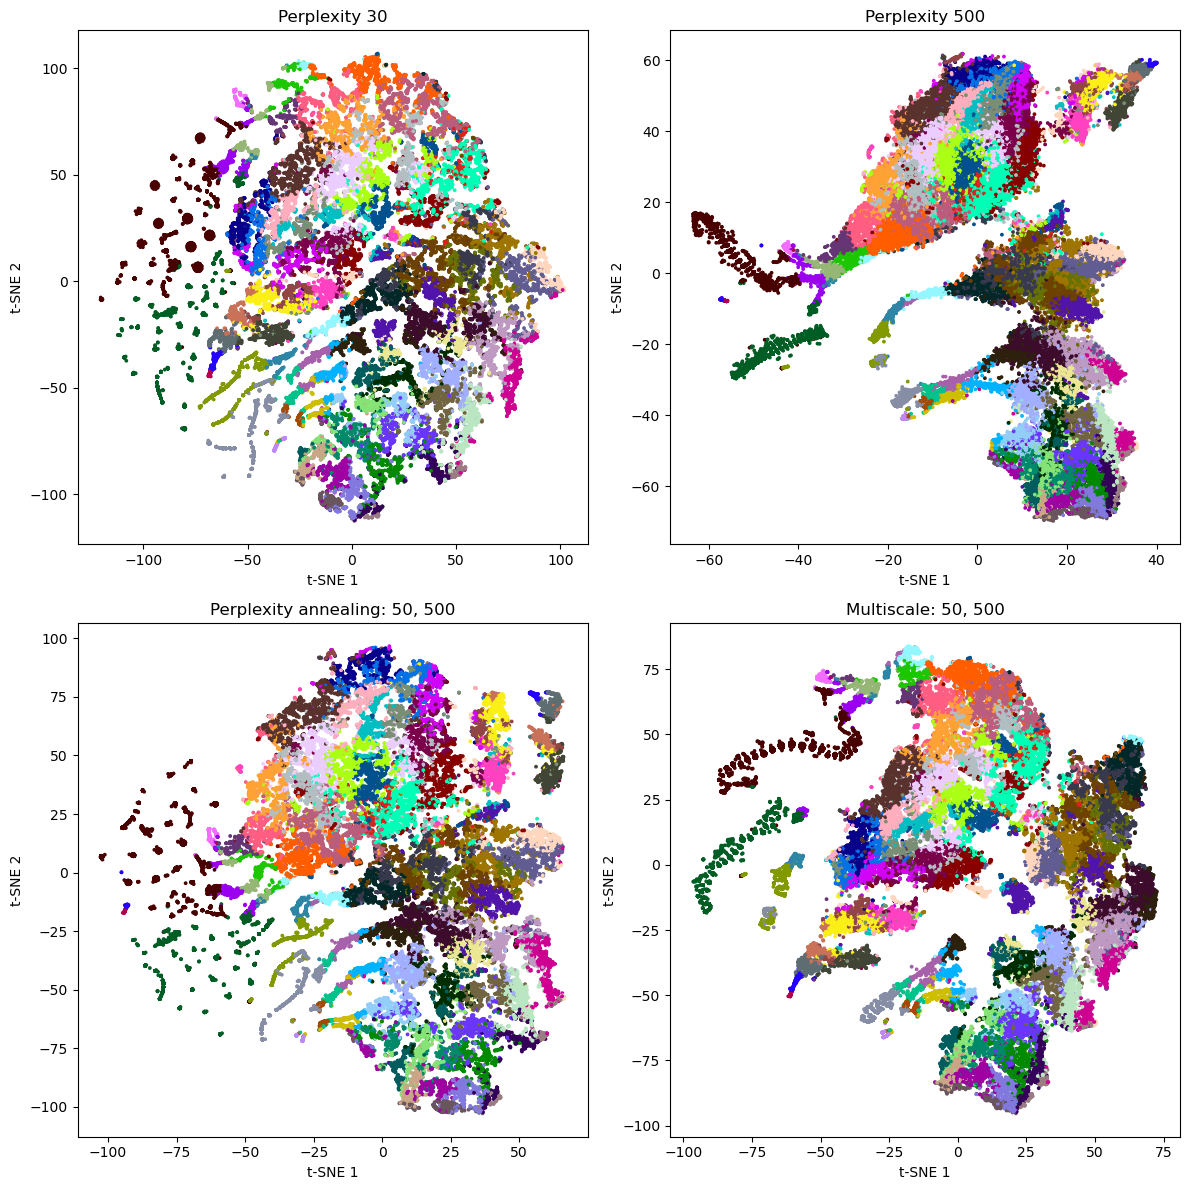

In [52]:
# Summary
fig, ax = plt.subplots(2, 2, figsize=(12, 12))

plot(embedding_pca_cosine, ax[0, 0], "Perplexity 30")
plot(embedding_pca_cosine_500, ax[0, 1], "Perplexity 500")
plot(embedding_annealing, ax[1, 0], "Perplexity annealing: 50, 500")
plot(embedding_multiscale, ax[1, 1], "Multiscale: 50, 500")

plt.tight_layout()
plt.show()